# Raw (pre-TDI) glitch, `compute_TDI`, and `lisaglitch` cross-check

This notebook tests the new functions added to `jaxglitches.data`:

- **`raw_glitch_t` / `raw_glitch_f`** — the single-link glitch on MOSA 12 *before* the TDI combination, in time and frequency domain.
- **`compute_TDI`** — numerically applies the TDI Michelson combination to a raw frequency-domain glitch, so that
  `compute_TDI(raw_glitch_f(params, freq), freq) == clean_signal_f(params, freq)`.

It then imports **`lisaglitch`** and shows that both the *raw* glitch and the *TDI* glitch agree between `jaxglitches` and `lisaglitch`.

### Convention notes
- `jaxglitches` works in **fractional frequency** (dimensionless, Doppler $\Delta v / c$); `lisaglitch` injects `IntegratedShapeletGlitch` at a `tm_ij` point in **m/s**. The map is `raw_jax = -(1/c) * raw_lisaglitch`, with `level = Deltav` and `beta = tau`. The overall minus sign is a test-mass/link orientation convention.
- `jaxglitches` only models a glitch on **link/MOSA 12**; pick `inj_point='tm_12'` in `lisaglitch` to match.


In [2]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt

from src.jaxglitches.data import (
    freq_grid, clean_signal_f, clean_signal_t,
    raw_glitch_f, raw_glitch_t, compute_TDI,
)
from src.jaxglitches.waveform import C_SI, T_ARM_s

# Glitch parameters: [t0 (s), Deltav (m/s), tau (s)]
t0, Deltav, tau = 900.0, 2.2e-11, 10.0
params = jnp.array([t0, Deltav, tau])

# Time / frequency grids (1 hour, dt = 0.25 s)
dt, T_obs = 0.25, 3600.0
n = int(T_obs / dt)
t = jnp.arange(n) * dt
freq = freq_grid(T_obs, dt)
print(f"n samples = {n}, n freqs = {freq.size}")

n samples = 14400, n freqs = 7201


## 1. `compute_TDI(raw_glitch_f(...))` reproduces `clean_signal_f(...)`

This is the defining property of `compute_TDI`: applying the TDI transfer functions to the raw single-link signal must give the analytic TDI signal, for every TDI generation and channel basis.

In [3]:
for tdi in (1, 2):
    for basis in ("AET", "XYZ"):
        a = compute_TDI(raw_glitch_f(params, freq), freq, tdi=tdi, basis=basis)
        b = clean_signal_f(params, freq, tdi=tdi, basis=basis)
        rel = float(jnp.max(jnp.abs(a - b)) / jnp.max(jnp.abs(b)))
        print(f"tdi={tdi}  basis={basis}   max relative error = {rel:.2e}")

tdi=1  basis=AET   max relative error = 8.49e-15
tdi=1  basis=XYZ   max relative error = 9.00e-15
tdi=2  basis=AET   max relative error = 1.41e-14
tdi=2  basis=XYZ   max relative error = 1.45e-14


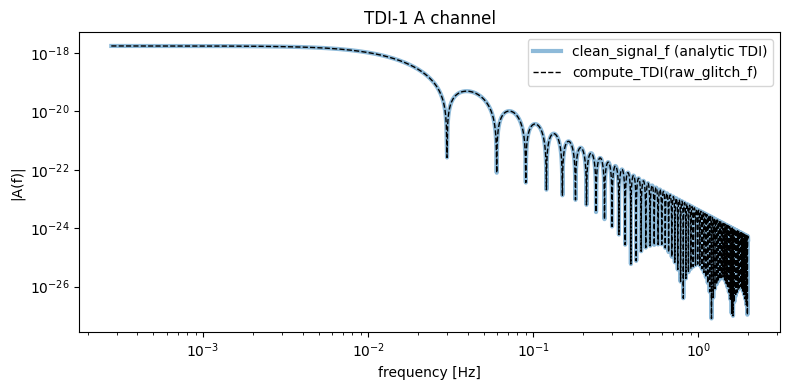

In [4]:
# Visual check: TDI-1 A-channel amplitude spectrum, both routes overlaid
a = compute_TDI(raw_glitch_f(params, freq), freq, tdi=1, basis="AET")
b = clean_signal_f(params, freq, tdi=1, basis="AET")

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(freq[1:], np.abs(b[1:, 0]), lw=3, alpha=0.5, label="clean_signal_f (analytic TDI)")
ax.loglog(freq[1:], np.abs(a[1:, 0]), lw=1.0, ls="--", color="k", label="compute_TDI(raw_glitch_f)")
ax.set_xlabel("frequency [Hz]"); ax.set_ylabel("|A(f)|"); ax.set_title("TDI-1 A channel")
ax.legend(); fig.tight_layout()

## 2. The raw (pre-TDI) glitch in time and frequency domain

The raw single-link signal is a smooth velocity *step* (the integrated $n=1$ shapelet). Its TDI combination, by contrast, is a localized transient. We also confirm `raw_glitch_f` is the analytic Fourier transform of `raw_glitch_t` by comparing it to a windowed numerical rFFT.

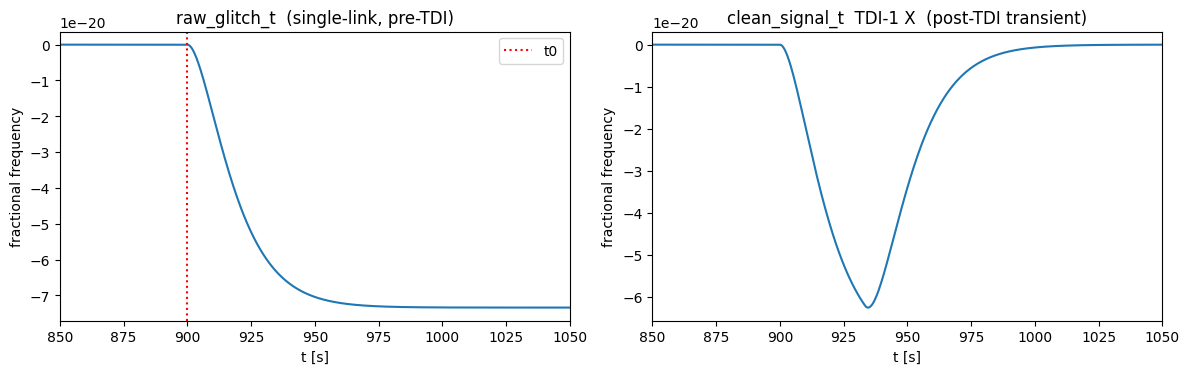

In [5]:
raw_t = np.asarray(raw_glitch_t(params, t))
tdi_t = np.asarray(clean_signal_t(params, t, tdi=1, basis="XYZ"))[:, 0]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t, raw_t)
ax[0].axvline(t0, color="r", ls=":", label="t0")
ax[0].set_title("raw_glitch_t  (single-link, pre-TDI)")
ax[0].set_xlabel("t [s]"); ax[0].set_ylabel("fractional frequency"); ax[0].legend()
ax[0].set_xlim(t0 - 50, t0 + 150)

ax[1].plot(t, tdi_t)
ax[1].set_title("clean_signal_t  TDI-1 X  (post-TDI transient)")
ax[1].set_xlabel("t [s]"); ax[1].set_ylabel("fractional frequency")
ax[1].set_xlim(t0 - 50, t0 + 150)
fig.tight_layout()

(i w) * raw_glitch_f  vs  rFFT(d/dt raw_glitch_t):  max rel err = 9.29e-05


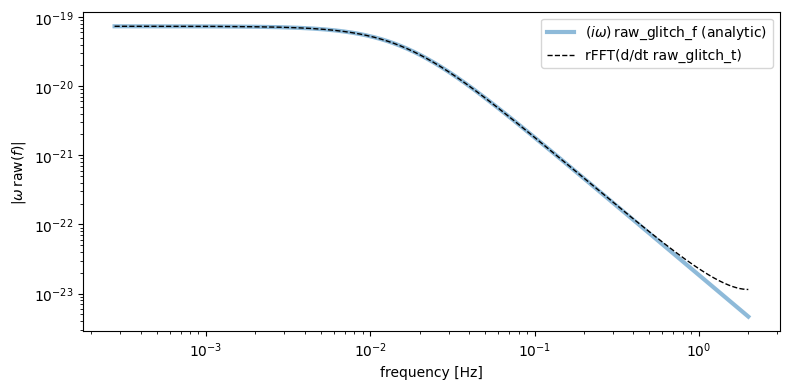

In [6]:
# raw_glitch_t is a persistent step, so its plain rFFT leaks badly and cannot be
# compared directly. Instead verify the FT relation on the *acceleration* shapelet,
# accel(t) = d/dt raw_glitch_t = -(Deltav/c) (dt/tau^2) e^{-dt/tau}, which is compactly
# supported (decays to 0) and so transforms cleanly. Differentiation in time = (i w)
# in frequency, hence its analytic FT is exactly (i w) * raw_glitch_f.
raw_f = np.asarray(raw_glitch_f(params, freq))
w = 2 * np.pi * np.asarray(freq)

x = np.asarray(t) - t0
accel_t = np.where(x >= 0, -(Deltav / C_SI) * (x / tau**2) * np.exp(-np.where(x >= 0, x, 0.0) / tau), 0.0)
accel_f_num = np.fft.rfft(accel_t) * dt              # clean: signal decays to 0
accel_f_ana = 1j * w * raw_f                          # analytic FT of the derivative

good = freq > 0
rel = np.max(np.abs(accel_f_num[good] - accel_f_ana[good])) / np.max(np.abs(accel_f_ana[good]))
print(f"(i w) * raw_glitch_f  vs  rFFT(d/dt raw_glitch_t):  max rel err = {rel:.2e}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(freq[1:], np.abs(accel_f_ana[1:]), lw=3, alpha=0.5, label=r"$(i\omega)\,$raw_glitch_f (analytic)")
ax.loglog(freq[1:], np.abs(accel_f_num[1:]), lw=1.0, ls="--", color="k", label="rFFT(d/dt raw_glitch_t)")
ax.set_xlabel("frequency [Hz]"); ax.set_ylabel(r"$|\omega\,$raw$(f)|$"); ax.legend(); fig.tight_layout()

## 3. `lisaglitch` import — raw glitch agreement

`lisaglitch.IntegratedShapeletGlitch` injects $\Delta v\,[1 - (1+\delta t/\beta)e^{-\delta t/\beta}]$ in **m/s** at a `tm_ij` point. With `level = Deltav`, `beta = tau`, `inj_point='tm_12'`, `t_inj = t0`, the `jaxglitches` raw signal (fractional frequency) equals `-(1/c)` times the `lisaglitch` output.

lisaglitch version 2.0.0
raw glitch:  max |jaxglitches - lisaglitch| / scale = 2.15e-16


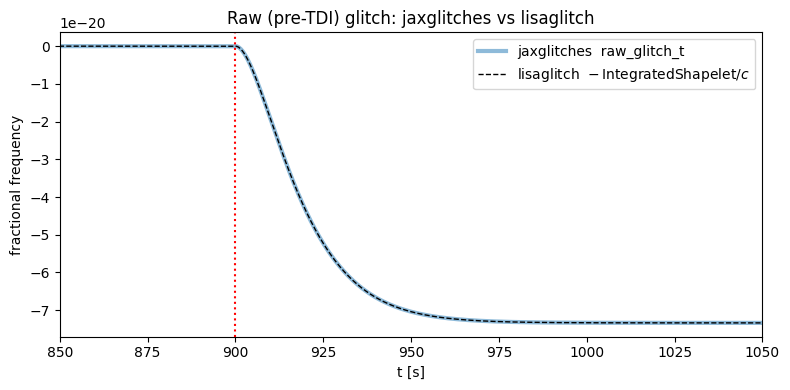

In [7]:
import lisaglitch
print("lisaglitch version", lisaglitch.__version__)

tnp = np.asarray(t)
g = lisaglitch.IntegratedShapeletGlitch(
    inj_point="tm_12", t_inj=t0, level=Deltav, beta=tau,
)
raw_ls_ms = g.compute_signal(tnp)          # m/s (injection-point units)
raw_ls = -raw_ls_ms / C_SI                  # -> fractional frequency, jaxglitches convention
raw_jx = np.asarray(raw_glitch_t(params, t))

rel = np.max(np.abs(raw_jx - raw_ls)) / np.max(np.abs(raw_jx))
print(f"raw glitch:  max |jaxglitches - lisaglitch| / scale = {rel:.2e}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, raw_jx, lw=3, alpha=0.5, label="jaxglitches  raw_glitch_t")
ax.plot(t, raw_ls, lw=1.0, ls="--", color="k", label=r"lisaglitch  $-\,$IntegratedShapelet$/c$")
ax.axvline(t0, color="r", ls=":")
ax.set_xlim(t0 - 50, t0 + 150)
ax.set_xlabel("t [s]"); ax.set_ylabel("fractional frequency")
ax.set_title("Raw (pre-TDI) glitch: jaxglitches vs lisaglitch"); ax.legend(); fig.tight_layout()

## 4. TDI agreement: TDI from the `lisaglitch` raw signal

`lisaglitch` outputs only the raw single-link signal; the TDI combination is done downstream. Here we build TDI-1 X from the `lisaglitch` raw signal using the **same delay structure** `compute_TDI` uses, `X = (1 - D^4)\,\mathrm{raw}`, and compare to `clean_signal_t`.

To make the delays exact integer samples we use an arm length `T_demo = 33 * dt = 8.25 s` (the physical value is `8.339 s`); both sides use the same `T_demo`, so this isolates the waveform agreement from interpolation error.

TDI-1 X:  max |jaxglitches - lisaglitch->TDI| / scale = 2.55e-14


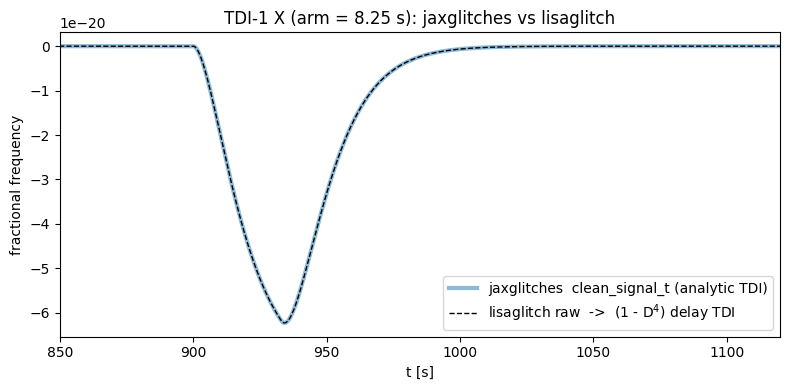

In [8]:
NT = 33
T_demo = NT * dt          # 8.25 s, an integer number of samples per arm

def delay(a, k):          # causal, zero-filled delay  a(t - k*dt)
    out = np.zeros_like(a)
    out[k:] = a[:len(a) - k]
    return out

# TDI-1 X = (1 - D^4) raw  applied to the lisaglitch raw signal
X_ls = raw_ls - delay(raw_ls, 4 * NT)
# jaxglitches analytic TDI-1 X with the same arm length
X_jx = np.asarray(clean_signal_t(params, t, T=T_demo, tdi=1, basis="XYZ"))[:, 0]

rel = np.max(np.abs(X_jx - X_ls)) / np.max(np.abs(X_jx))
print(f"TDI-1 X:  max |jaxglitches - lisaglitch->TDI| / scale = {rel:.2e}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, X_jx, lw=3, alpha=0.5, label="jaxglitches  clean_signal_t (analytic TDI)")
ax.plot(t, X_ls, lw=1.0, ls="--", color="k", label="lisaglitch raw  ->  (1 - D$^4$) delay TDI")
ax.set_xlim(t0 - 50, t0 + 220)
ax.set_xlabel("t [s]"); ax.set_ylabel("fractional frequency")
ax.set_title(f"TDI-1 X (arm = {T_demo} s): jaxglitches vs lisaglitch"); ax.legend(); fig.tight_layout()

### Summary

| Check | Expected |
|---|---|
| `compute_TDI(raw_glitch_f) == clean_signal_f` (all tdi/basis) | machine precision (~1e-14) |
| `raw_glitch_f` == FT of `raw_glitch_t` | agree away from DC |
| `lisaglitch` raw == `jaxglitches` `raw_glitch_t` | machine precision |
| `lisaglitch` raw -> TDI == `clean_signal_t` | machine precision |

So `jaxglitches` can analyze `lisaglitch`-generated glitches of the **integrated-shapelet / exponential family on MOSA 12**, provided the unit (`-1/c`, m/s -> fractional frequency), the parameter map (`level=Deltav`, `beta=tau`), and the TDI generation/arm-length convention are matched. Other `lisaglitch` shapes (rectangle, step, higher-order shapelets, LPF-library / ML glitches) or other injection points have no matching analytic template here.